# Insurance Pricing Model: Modeling

We are skipping deeper preprocessing and jumping straight into modeling.

Today we compare three approaches:

1. **Ordinary Least Squares Regression** (OLS)
2. **Generalized Linear Model** (GLM)
3. **Gradient Boosting Machine** (GBM via XGBoost)

The goal: compare out-of-sample performance.

# Packages and Settings

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
import optuna

from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from utils import *

# Import Data

In [21]:
df = pd.read_parquet("data/df_train.parquet")

# Train Ordinary Least Squares Regression

OLS is not designed for insurance losses.

I’m fitting it because it is likely the model you are most familiar with.

After we look at the output, we’ll discuss why it is a poor choice for this type of data.

In [22]:
y_col = "pure_premium_capped_1MIL"

cat_cols = ["Area", "VehBrand", "VehGas", "Region"]
num_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

rhs = " + ".join(
    [f"C({c})" for c in cat_cols] + num_cols
)

formula = f"{y_col} ~ {rhs}"

ols = smf.ols(
    formula=formula,
    data=df
).fit() 

print(ols.summary())

                               OLS Regression Results                               
Dep. Variable:     pure_premium_capped_1MIL   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     1.984
Date:                      Fri, 27 Feb 2026   Prob (F-statistic):           0.000152
Time:                              22:39:35   Log-Likelihood:            -6.3971e+06
No. Observations:                    542410   AIC:                         1.279e+07
Df Residuals:                        542367   BIC:                         1.279e+07
Df Model:                                42                                         
Covariance Type:                  nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

The coefficient estimates are in the “coef” column.

The P>|t| column gives the p-value for testing whether each coefficient is significantly different from zero.

If the model assumptions are valid, this is useful information.

The model ran.
We have coefficients.
We have p-values.

So we’re done...right?

Not quite.

Why is this not a good idea for insurance losses?

What assumptions is OLS making that might not hold here?

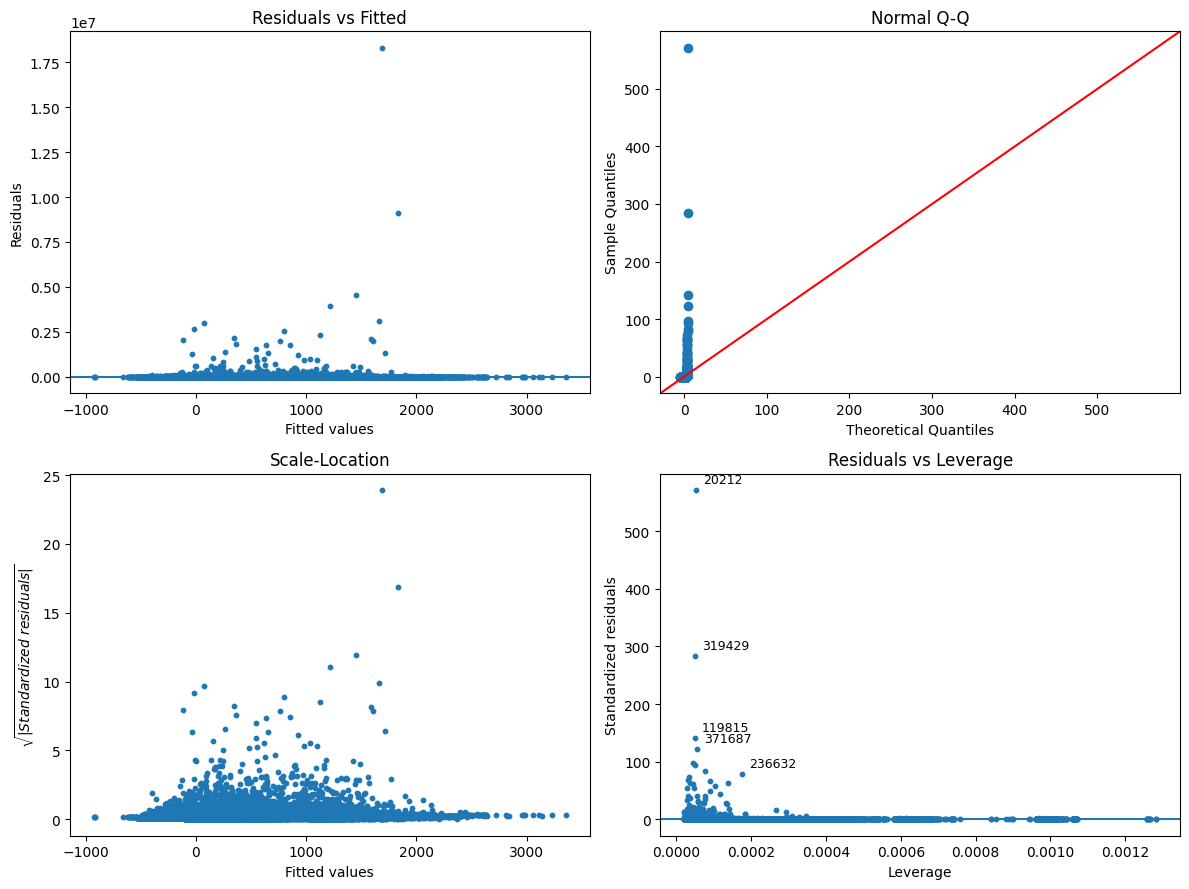

In [23]:
fitted = ols.fittedvalues
resid = ols.resid

infl = ols.get_influence()
std_resid = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.ravel()

# 1) Residuals vs Fitted
ax1.scatter(fitted, resid, s=10)
ax1.axhline(0)
ax1.set_title("Residuals vs Fitted")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")

# 2) Normal Q-Q
sm.qqplot(std_resid, line="45", ax=ax2)
ax2.set_title("Normal Q-Q")

# 3) Scale-Location
ax3.scatter(fitted, np.sqrt(np.abs(std_resid)), s=10)
ax3.set_title("Scale-Location")
ax3.set_xlabel("Fitted values")
ax3.set_ylabel(r"$\sqrt{|Standardized\ residuals|}$")

# 4) Residuals vs Leverage (label a few high Cook's distance points)
ax4.scatter(leverage, std_resid, s=10)
ax4.axhline(0)
ax4.set_title("Residuals vs Leverage")
ax4.set_xlabel("Leverage")
ax4.set_ylabel("Standardized residuals")

# label top 5 Cook's distance points
top = np.argsort(cooks)[-5:]
for i in top:
    ax4.annotate(str(i), (leverage[i], std_resid[i]), xytext=(5, 5),
                 textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.show()

Ordinary least squares regression has some assumptions behind it. If any of those assumptions are violated, the model is invalid.

Does anyone remember the assumptions?

(Don't scroll down yet)

1. Linearity: The mean of Y is a linear function of the predictors.
2. Independence: Observations (errors) are independent of each other.
3. Constant variance (Homoskedasticity): The error variance is the same for all fitted values.
4. Normality of errors: The errors are approximately normally distributed. This is *technically* necessary for inference, but not strictly necessary for prediction.

In the above diagnostic plots, we see a clear violation of a couple of these assumptions:

1. Residuals vs Fitted and Scale-Location plots clearly show a violation of assumption #3: the variance is NOT constant and does not depend on the mean.
2. The QQ-plot clearly shows a violation of assumption #4: the residuals are not close to that straight line- they are NOT normal. They show signs of extreme skewness.

Some more bad things:

1. There are some high-leverage outlier observations driving the model fit (see Residuals vs Leverage plot)
2. See below- fitted values are nonsensical.

In [24]:
print(ols.fittedvalues.sort_values().head(10))
print(f"{((ols.fittedvalues < 0).sum() / len(ols.fittedvalues)).round(3) * 100}% of our training data has a negative prediction.")

131057   -927.553123
43221    -915.685883
43222    -915.685883
61613    -665.486997
82497    -618.210978
82498    -618.210978
536337   -616.237754
401152   -604.370514
241711   -592.503273
145428   -592.379954
dtype: float64
16.0% of our training data has a negative prediction.


The model predicts negative values for some risks.

That means if we used this model, we would be paying customers to insure with us.

That’s insane.

It sounds unbelievable that someone would use OLS for insurance losses- but it happens.

When I first became a pricing modeler, I inherited a production model built exactly like this. It was being used to price tens of millions of dollars of premium- and yes, it predicted negative pure premium for some risks.

One of the first things I did was fix that problem.

# Train Generalized Linear Model

While this trains (takes about 90 seconds)...

What makes a GLM different from OLS?

In a GLM:

- We choose the error distribution (it isn't assumed to be normal)
- You choose the link function
- The variance can depend on the mean (it isn't necessarily constant)

In fact, OLS is just a special case of a GLM where we assume *constant* variance and normal error distribution.

We discussed earlier that insurance losses:

- Have a point mass at 0
- Are highly skewed for positive values

There is a distribution designed for exactly this situation: the Tweedie distribution, also called a Compound Poisson-Gamma distribution.

The variance structure is:

$\operatorname{Var}(Y) = \sigma^2 \mu^{p}$

Unlike OLS, variance is allowed to grow with the mean.

- Normal distribution has two parameters: $\mu$ and $\sigma$
- Binomial has one: $p$
- Poisson has one: $\lambda$
- Tweedie also has one key shape parameter: $p$

Tweedie's $p$ parameter controls how skewed the distribution is. Here are some simulated examples for different values of $p$:

![Tweedie power demo](./img/tweedie_power_demo.png)

For our data, I performed some analysis outside of this project to estimate this parameter for our data at 1.85. I pass this parameter to the GLM fit.


We also use a log-link. This is common practice. We are fitting estimates to coefficients in this formula:

$$
\begin{aligned}
\log\!\big(\mathbb{E}[\text{pure\_premium\_capped\_1MIL}]\big)
&= \beta_0
+ \beta_1 \,\text{VehPower}
+ \beta_2 \,\text{VehAge}
+ \beta_3 \,\text{DrivAge} \\
&\quad
+ \beta_4 \,\text{BonusMalus}
+ \beta_5 \,\text{Density}
+ \sum_j \gamma_j \,\mathbb{1}(\text{Area}=j)
+ \sum_k \delta_k \,\mathbb{1}(\text{VehBrand}=k) \\
&\quad
+ \sum_m \eta_m \,\mathbb{1}(\text{VehGas}=m)
+ \sum_r \theta_r \,\mathbb{1}(\text{Region}=r)
\end{aligned}
$$

In [25]:
glm = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Tweedie(var_power=1.85, link=sm.families.links.Log())
).fit()

In [26]:
print(glm.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     pure_premium_capped_1MIL   No. Observations:               542410
Model:                                  GLM   Df Residuals:                   542367
Model Family:                       Tweedie   Df Model:                           42
Link Function:                          Log   Scale:                          4257.9
Method:                                IRLS   Log-Likelihood:            -3.1548e+05
Date:                      Fri, 27 Feb 2026   Deviance:                   1.8870e+07
Time:                              22:41:05   Pearson chi2:                 2.31e+09
No. Iterations:                          89   Pseudo R-squ. (CS):          0.0003753
Covariance Type:                  nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

Okay! This is better. 

But it is by no means perfect.

Let me highlight a few limitations.

## Model Structure Limitations

1. We are still fitting straight lines to the numeric variables. During EDA, we saw those relationships are not purely linear.
2. Some categorical levels are very small and potentially uncredible.
3. We are not including any interaction terms.

All of that was intentional for simplicity- but these choices limit performance.

## Are These Variables Actually Useful?

Look at the P>|z| column for Area B. Area B is not statistically significant.

So should we remove it? In fact, most Areas aren't significant. You can’t just remove one level of a categorical variable. What would we label those observations? 

One common solution here is binning- combining categorical levels. Instead of “Area B” and “Area C,” we might group them together. You keep refining until the structure makes statistical and business sense.

But it is important to understand that p-values are tools for inference. Pricing models are not always built for inference- sometimes we only care about predictive accuracy. So I don't rely on p-values alone when building a pricing model.

## Risk of Overfitting vs Underfitting

Is this model overfit? 

Probably not. We only used 42 degrees of freedom with over 500,000 observations.

If anything, parts of this model are likely underfit- especially the numeric variables.

From here, I would normally move to:

- Splines for numeric variables
- Interaction terms
- Regularization

But that process takes time and careful tuning.

This is where our next model becomes interesting...

# Train a Gradient Boosting Machine

This next code chunk takes around 10 minutes to run. Conceptually, this is a big jump. We're moving into a much more advanced modeling approach.

The GLM that we’ve discussed so far fits within what the industry calls “traditional” actuarial methods.

Now I’m going to show you what is commonly labeled a *machine learning* technique.

That terminology is messy- GLMs are technically machine learning too- but in practice, when actuaries say “machine learning,” they usually mean models like this.

Very few actuaries are directly filing GBMs with regulators for pricing. I am fortunate enough to work at a company that is pushing the industry forward into using tools like this model. I think you'll be able to see why this technique is so powerful.

## Decision Trees

At the core of this method is a decision tree.

A tree repeatedly splits the data using simple rules. For example: BonusMalus $\le 1.2$ and BonusMalus $\gt 1.2$.

Each split is chosen to make the groups more similar in terms of losses.

An observation moves through the splits until it reaches a final node, which gives a prediction.

## Boosting

A GBM starts with one tree. Then it builds another tree to correct the errors of the first. Then another. And another.

Each tree focuses on what the previous trees got wrong. The final prediction is the sum of all trees.

This allows the model to capture non-linear relationships, interaction effects and complex structure without us manually specifying them. That's a major difference from the GLM we've trained above.

## XGBoost

XGBoost is a highly optimized implementation of gradient boosting. It adds regularization, efficient computation and advanced controls. It is extremely powerful and widely used in modern machine learning.

## Downsides

- No clean formula
- No single set of coefficients
- No simple hypothesis tests
- Interpretability becomes harder. There is an entire research area- Interpretable Machine Learning- devoted to understanding these models.

This is a trade-off.

## Hyperparameter Tuning

This model has many settings controlling how exactly those underlying decision trees work. There are an enormous number of possible combinations (trillions). We cannot try them all. So we use Optuna, a hyperparameter optimization library. Instead of brute-force grid search, Optuna uses a Bayesian-style algorithm. It learns from earlier trials and focuses on promising regions of the parameter space. Over time, it narrows in on strong configurations efficiently. In this demo, I allow it a fairly low fixed number of trials. After tuning, we retrain the model on the full dataset using the best settings found.

In [27]:
study, best_params, best_num_boost_round, train_categories = tune_xgb_tweedie_optuna(
    df=df,
    cat_cols=cat_cols,
    num_cols=num_cols,
    y_col=y_col,
    exposure_col="Exposure",
    n_splits=5,
    n_trials=25,
    random_state=42,
)

[I 2026-02-27 22:41:07,128] A new study created in memory with name: no-name-b9e64f02-4731-4e32-bf91-093f83e21424
c:\Users\jwrth\Documents\Projects\Portfolio\Actuarial Data Science Presentation\.venv\Lib\site-packages\optuna\distributions.py:671: UserWarning: The distribution is specified by [1, 100000] and step=5000, but the range is not divisible by `step`. It will be replaced with [1, 95001.0].
  optuna_warn(
[I 2026-02-27 22:41:27,282] Trial 0 finished with value: 18.115822878954603 and parameters: {'tweedie_variance_power': 1.9, 'eta': 0.08, 'max_depth': 2, 'min_child_weight': 55001.0, 'gamma': 2.5, 'subsample': 0.5, 'colsample_bytree': 0.65, 'lambda': 21.0, 'alpha': 6.0, 'max_delta_step': 3.0, 'max_cat_to_onehot': 15, 'max_cat_threshold': 52}. Best is trial 0 with value: 18.115822878954603.
[I 2026-02-27 22:41:43,075] Trial 1 finished with value: 110.80822708013434 and parameters: {'tweedie_variance_power': 1.35, 'eta': 0.11, 'max_depth': 5, 'min_child_weight': 5001.0, 'gamma': 6

Above, I ran 25 trials. Each trial represents one different combination of hyperparameters. Optuna evaluates each combination using cross-validation and records the resulting performance metric.

You can see that early on, performance varies quite a bit. It finds a reasonably strong configuration within the first few trials. However, it doesn’t immediately settle on the best one. It continues exploring other regions of the parameter space, sometimes performing much worse, sometimes slightly better.

Late in the process, it finds an even stronger configuration than the earlier candidates. That illustrates how the Bayesian optimization process works. It doesn’t just randomly sample combinations. Instead, it learns from earlier trials and increasingly focuses on regions of the parameter space that appear promising.

The entire process took about 15 minutes. I could increase the number of trials to potentially squeeze out slightly better performance, but that would increase runtime. In a real production setting, spending more time on tuning is usually worthwhile to a point, but after a while you don't get meaningful improvement. For this presentation, 25 trials is sufficient to demonstrate how the process works and to obtain a well-performing model.

In [28]:
X, y, w, base_score = make_X_y(df, cat_cols, num_cols, y_col, "Exposure")

dtrain_full = xgb.DMatrix(X, label=y, weight=w, enable_categorical=True)
xgb_tw = xgb.train(
    params=best_params,
    dtrain=dtrain_full,
    num_boost_round=best_num_boost_round,
)

print("Best CV tweedie-nloglik:", study.best_value)
print("Best params:", best_params)

Best CV tweedie-nloglik: 16.265120969230914
Best params: {'objective': 'reg:tweedie', 'tweedie_variance_power': 1.85, 'eval_metric': 'tweedie-nloglik@1.85', 'base_score': 5.05696907351396, 'tree_method': 'hist', 'seed': 42, 'eta': 0.02, 'max_depth': 3, 'min_child_weight': 15001.0, 'gamma': 8.5, 'subsample': 0.65, 'colsample_bytree': 0.9, 'lambda': 39.0, 'alpha': 10.0, 'max_delta_step': 3.5, 'max_cat_to_onehot': 6, 'max_cat_threshold': 50}


# Out of Sample Performance

So, objectively, which model is best?

That sounds like a simple question, but it depends entirely on how we define “best.”

The way I’m going to answer that question is by evaluating each model on a **holdout** dataset. Before we began modeling, I set aside a portion of the data that the models have never seen. None of the models were trained on it, and none of the tuning procedures used it.

Now, I will take each fitted model and generate predictions on that holdout data- without refitting anything. This gives us an honest assessment of out-of-sample performance.

That is what really matters in pricing: not how well the model fits the training data, but how well it predicts new, unseen risks.

To evaluate performance, I’ll use two metrics that are common in insurance pricing.

The first is a **lift chart**, which helps us understand how well the model ranks risks from lowest to highest expected loss.

The second is an **Ordered Lorenz Curve**, which summarizes ranking performance using a statistic called the **Gini index**.

Both methods focus on how effectively the model differentiates between good and bad risks, which is central to pricing accuracy.

In [29]:
df_test = pd.read_parquet("data/df_test.parquet")
df_test["pred_ols"] = ols.predict(df_test)
df_test["pred_glm"] = glm.predict(df_test)

X_test = preprocess_for_predict(df_test, cat_cols, num_cols)
dtest = xgb.DMatrix(X_test, enable_categorical=True)
df_test["pred_xgb"] = xgb_tw.predict(dtest)
df_test["pred_int"] = (df['Exposure'] * df['pure_premium_uncapped']).sum() / df['Exposure'].sum()
y_test_col = 'pure_premium_capped_1MIL'
y_test = df_test[y_test_col]

## OLS Performance

 decile    exposure  actual_pp     pred_pp  actual_lift  pred_lift
      1 7160.719546 181.924515 -163.303094     1.178398  -0.468986
      2 7161.315962 118.016216   -5.240632     0.764438  -0.015050
      3 7161.276462 101.661295   86.065882     0.658501   0.247171
      4 7161.181615 127.855111  168.043027     0.828169   0.482599
      5 7161.504781 109.718382  252.858448     0.710690   0.726178
      6 7160.749855 123.590290  336.101832     0.800544   0.965243
      7 7161.749409 122.568995  420.309009     0.793929   1.207076
      8 7161.145095 177.336773  533.739526     1.148681   1.532834
      9 7160.877324 145.060892  720.904352     0.939618   2.070349
     10 7161.622593 336.090960 1132.507842     2.176996   3.252424


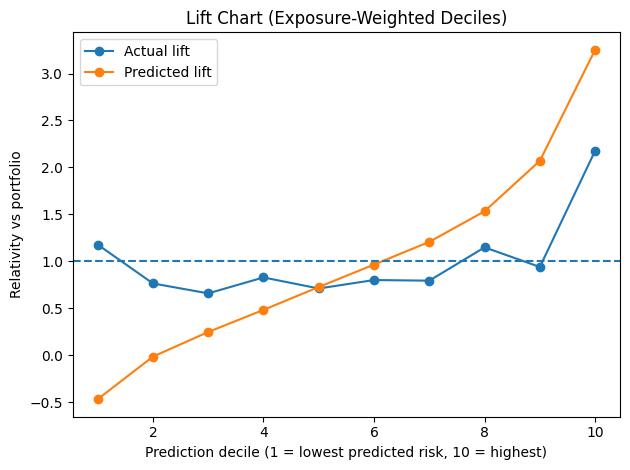

In [30]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col=y_test_col, pred_pp=df_test["pred_ols"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

Along the x-axis, the data are divided into 10 equal-exposure groups, ordered by the model’s prediction- in this case, the OLS prediction. The first decile contains the risks the model believes are the lowest cost, and the tenth decile contains the risks it believes are the highest cost.

Within each decile, we calculate two numbers: the average predicted pure premium and the average actual pure premium. The orange line shows the predicted values, and the blue line shows the actual outcomes.

In an ideal model, two things would happen. First, the blue line would increase steadily from left to right, meaning the model correctly ranked risks from lowest to highest loss. Second, the blue and orange lines would closely align, meaning the model not only ranked correctly but also predicted the right level of loss within each group.

In this chart, neither condition holds very well. The lines do not align, and the actual line is relatively flat compared to the predictions. This tells us that the OLS model is not doing a good job distinguishing low-risk from high-risk policies, and it is not accurately estimating price levels for new data.

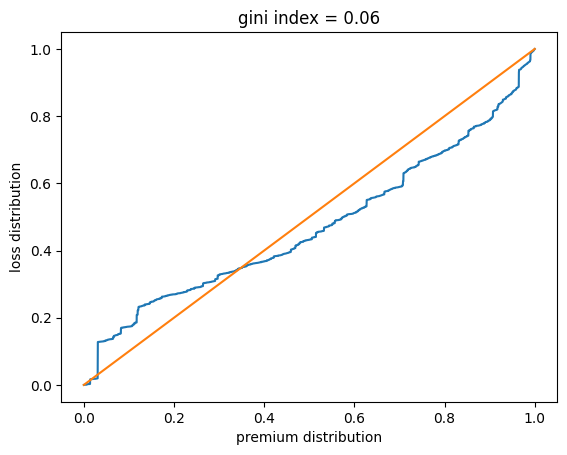

np.float64(0.059230199039197684)

In [31]:
orderedLorenz(df_test[y_test_col], df_test['pred_int'], df_test['pred_ols'], plot=True)

This figure is an Ordered Lorenz Curve, and it is used to compute the Gini index, which measures how well a model ranks risks.

On this chart, the orange line represents an intercept-only model- in other words, charging everyone the same flat price. The blue line represents the OLS model’s predictions.

The idea is to compare how well each pricing scheme concentrates losses among the highest-risk policies. If a model ranks risks well, its curve should lie consistently below the flat-pricing line. That means the policies the model identifies as “low risk” truly contain a smaller share of total losses, and the high-risk policies contain a larger share.

In this case, the blue curve crosses above the orange line in the early portion of the graph. That means the policies the model ranked as the lowest risk actually contain more than their proportional share of losses. In other words, we are underpricing those risks. The lift chart showed the same issue; this is another way to see it.

The Gini index summarizes this visually by measuring the area between the two curves. Because portions of the blue curve sit above the orange line, those regions count negatively, which reduces the overall Gini value.

Taken together, this confirms that OLS performs poorly for ranking and pricing. Combined with the earlier violations of model assumptions, this would make us very cautious about using OLS for insurance loss modeling.

## GLM Performance

 decile    exposure  actual_pp     pred_pp  actual_lift  pred_lift
      1 7161.062385 148.184134   95.195777     0.959848   0.274158
      2 7160.570689 114.422508  139.946781     0.741160   0.403038
      3 7161.371311 147.714388  172.479311     0.956805   0.496729
      4 7161.764408  74.971395  200.477597     0.485620   0.577363
      5 7161.003668 128.092237  226.981521     0.829705   0.653692
      6 7160.701872 118.198645  256.934872     0.765620   0.739956
      7 7161.033867 155.063212  298.022733     1.004407   0.858287
      8 7161.633655 154.848972  367.578999     1.003019   1.058604
      9 7161.729942 162.916695  511.134220     1.055277   1.472034
     10 7161.270844 339.413947 1203.507173     2.198520   3.466024


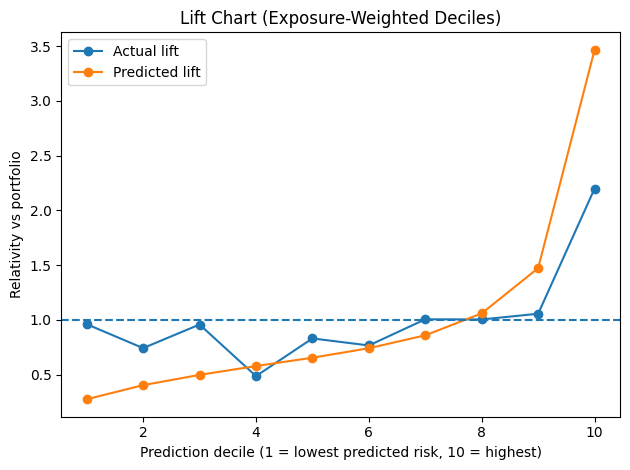

In [32]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col=y_test_col, pred_pp=df_test["pred_glm"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

The GLM shows some improvement relative to OLS, but the gains are modest.

The predicted and actual lines align slightly better, and the overall ranking appears somewhat improved. However, there is still a noticeable issue in the lower deciles. The model classifies certain risks as low cost, yet their actual loss experience is meaningfully higher than predicted.

This indicates that the GLM is still struggling to properly distinguish the safest risks from the rest of the portfolio. While it corrects some of the structural problems we saw with OLS, it has not fully captured the underlying complexity in the data.

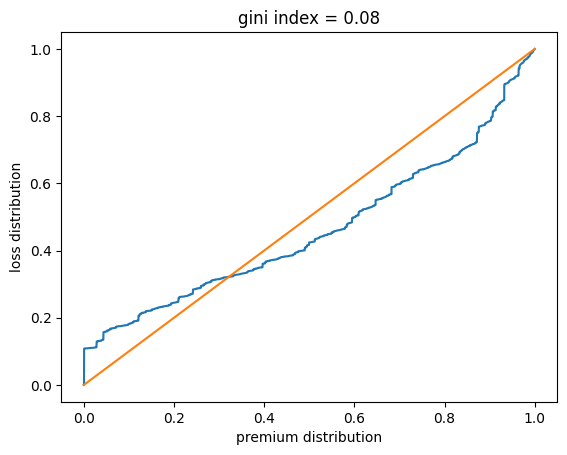

np.float64(0.07535633110348394)

In [33]:
orderedLorenz(df_test[y_test_col], df_test['pred_int'], df_test['pred_glm'], plot=True)

The Lorenz curve for the GLM reflects a slight improvement over OLS, but the overall picture is still underwhelming.

The curve stays below the flat-pricing line more consistently than OLS, which indicates some improvement in ranking performance. However, the separation between the curves is still relatively small, and there are regions where the model does not clearly differentiate low-risk from high-risk policies.

This is reflected in the Gini index, which is only marginally higher than that of the OLS model. In other words, while the GLM corrects the inappropriate distributional assumptions of OLS, it does not dramatically improve the model’s ability to rank risks out of sample.

Given the limited effort we invested in refining the GLM- no splines, no interaction terms, no extensive binning- this result is not surprising. With more work, performance could likely improve. But in its current form, the GLM remains constrained in its ability to capture more complex structure in the data.

## GBM Performance

 decile    exposure  actual_pp    pred_pp  actual_lift  pred_lift
      1 7160.389865  38.287447  49.222323     0.248003   0.367192
      2 7161.393536 142.489600  70.094061     0.922962   0.522892
      3 7161.703822 117.738381  82.822829     0.762639   0.617847
      4 7160.948525  92.839399  91.857770     0.601358   0.685246
      5 7161.298671 126.503373 100.223690     0.819413   0.747655
      6 7161.190651 110.554486 112.083465     0.716106   0.836127
      7 7160.777765 139.604684 127.965305     0.904276   0.954603
      8 7161.857446 158.952055 154.711414     1.029596   1.154125
      9 7161.069984 191.154557 198.938366     1.238185   1.484052
     10 7161.512377 425.680549 352.572598     2.757304   2.630142


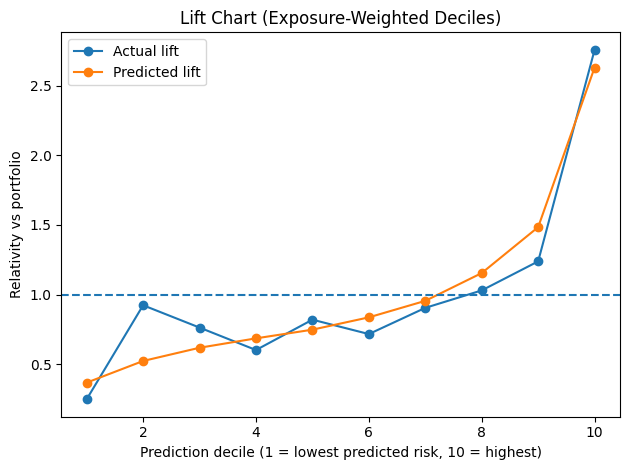

In [34]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col=y_test_col, pred_pp=df_test["pred_xgb"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

The GBM lift chart looks materially different.

The actual and predicted lines align much more closely across the deciles. More importantly, the blue line increases steadily from left to right, indicating that the model is ranking risks effectively from lowest to highest expected loss.

The separation between the lower and upper deciles is also much clearer. The lowest-risk deciles truly contain lower average losses, and the highest deciles contain substantially higher losses.

This tells us the GBM is doing two things well: it is ranking risks accurately, and it is predicting the relative price levels much more appropriately than the previous models.

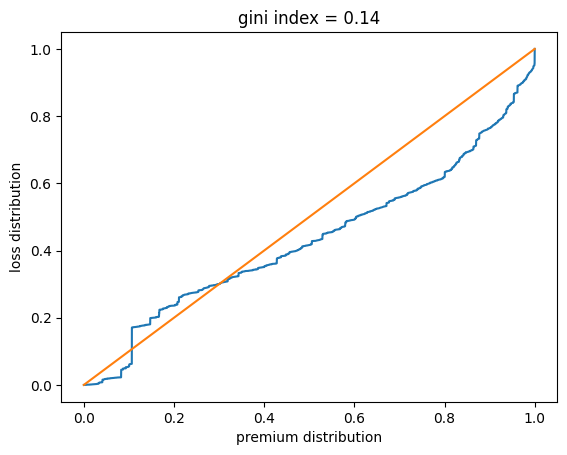

np.float64(0.13645141837478902)

In [35]:
orderedLorenz(df_test[y_test_col], df_test['pred_int'], df_test['pred_xgb'], plot=True)

The GBM curve stays consistently below the flat-pricing benchmark and shows a much larger separation. This means losses are more concentrated in the higher-risk portion of the portfolio according to the model’s ranking.

The Gini index is substantially higher than both OLS and GLM. That higher value reflects stronger discriminatory power — the model is better at distinguishing between low-risk and high-risk policies.

It is important to note that the curve is not perfect. There are still areas where the model could improve. In practice, this is where we would look for additional features or refinements. But relative to the other two approaches, the improvement is clear and meaningful.

## Compare GBM to GLM

Up to this point, we’ve compared each model to a flat-pricing benchmark. Now we can compare the GBM directly against the GLM.

This Lorenz curve uses the GLM as the baseline and evaluates whether the GBM provides incremental ranking improvement beyond it.

If the GBM truly adds value, its curve should consistently lie below the GLM curve. That would indicate that, for any proportion of the portfolio, the GBM better concentrates losses in the higher-risk segment.

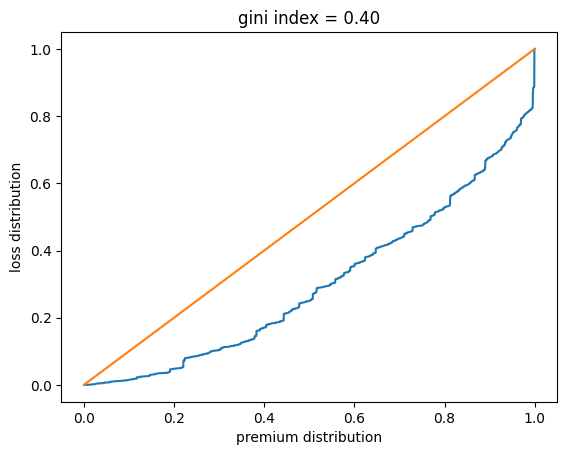

np.float64(0.4009750886778267)

In [36]:
orderedLorenz(df_test[y_test_col], df_test['pred_glm'], df_test['pred_xgb'], plot=True)

In this case, the separation is clear. The GBM dominates the GLM across nearly the entire range, and the resulting Gini improvement is substantial.

This confirms what we observed in the lift charts: the GBM provides materially stronger out-of-sample discriminatory power than the GLM in its current form.

# Conclusions

Overall, the GBM method clearly outperforms the GLM in terms of out-of-sample lift and Gini. This is not surprising, as the GBM is able to recognize non-linear patterns and interaction effects automatically, while our GLM is constrained by overly-restrictive linearity assumptions and contains no interaction terms. The GBM can flexibly adapt to complex structures in the data without requiring us to manually specify transformations, which gives it a natural advantage in predictive performance.

So why doesn’t everyone just use a GBM? The answer is that predictive accuracy is only one dimension of model quality. GLMs are transparent, stable, and easy to interpret: coefficients have a direct and explainable meaning, and the effect of each variable can be communicated clearly to stakeholders, regulators, and business users. They are also easier to validate, audit, and stress-test. In regulated industries like insurance, that interpretability and governance matter a great deal. GBMs, while powerful, are more complex and harder to explain, can be more sensitive to hyperparameter choices, and may require more computational resources and monitoring to ensure stability over time. In practice, the choice between GLM and GBM is not simply about performance, but about balancing accuracy, interpretability, governance, and operational considerations.

A brand new [CAS Monograph 16](https://www.casact.org/publications-research/publications/flagship-publications/cas-monographs/monograph-no-16), released in February 2026, goes into detail about the extensive effort modelers undertake to enhance GLMs so they can compete with modern machine learning approaches. Careful variable selection, thoughtful feature engineering, interaction testing, credibility adjustments, and repeated diagnostics can take months of disciplined work. By contrast, a well-configured GBM can often deliver strong performance in a matter of hours or even minutes once the data pipeline is in place. That contrast- months of structured statistical craftsmanship versus relatively rapid automated optimization- highlights an important industry conversation. The debate is no longer simply “Which model predicts better?” but rather “What trade-offs are we willing to make between speed, transparency, control, and incremental predictive lift?”